In [51]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Concatenate, GlobalAveragePooling2D, LSTM, BatchNormalization, GRU, Attention, GlobalAveragePooling1D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Dropout
import numpy as np
import pandas as pd
import xgboost as xgb
import io
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping
import os
import math
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rc
import seaborn as sns
%matplotlib inline
#맥에서 한글 안깨지게


rc('font', family='AppleGothic') # 애플 폰트 사용
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 안깨지게 설정|

In [3]:
# 1-1. 사용자 설정 경로 및 변수
GANGNAM_DIRECTORY = '../../data/raw/'
IMAGE_DIRECTORY = '../../data/interim/satellites/gang_nam_rot_90'

TABULAR_DATA_PATH = '../../data/interim/gang_nam_sendimental_score_with_sale.csv'

IMAGE_EXTENSION = '.jpg' # 이미지 파일 확장자 (.png, .jpeg 등)
DATE_COLUMN = '계약일자'
TARGET_COLUMN = '면적당 단가(만원)' # 예측할 실제 타겟 컬럼명

# 1-2. 모델 파라미터
LOOKBACK = 10      # 과거 10개의 거래 데이터를 보고 다음 거래를 예측
BATCH_SIZE = 64
EPOCHS = 100

In [4]:
# 2-1. CSV 파일 로드 및 날짜 기준 정렬
#print("1. 데이터를 로드하고 정렬합니다...")
df = pd.read_csv(TABULAR_DATA_PATH)
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN])
df = df.sort_values(DATE_COLUMN).reset_index(drop=True)
df.drop(columns=['sentiment_score'], axis=1, inplace=True)
df.head()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
0,84.73,5,1994,7.399156,24,2018-07-01,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5
1,169.19,4,2003,6.753467,15,2018-07-01,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5
2,84.43,10,1980,7.618163,38,2018-07-02,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5
3,76.79,4,1979,7.570627,39,2018-07-02,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5
4,162.51,1,1999,6.898420,19,2018-07-02,94.7,11215836.0,111.9,113.4,0.692,2.975,98.3,183.0,18.0,1.5


In [5]:
df.describe()

,전용면적(㎡),층,건축년도,면적당 단가(만원),아파트 나이,계약일자,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
count,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561,21561.000000,2.156100e+04,21561.000000,21561.000000,21561.000000,21561.000000,21561.00000,21561.000000,21561.000000,21561.000000
mean,89.029772,9.551691,1998.917304,7.705838,22.522749,2021-12-10 19:21:45.857798912,105.902365,1.253241e+07,117.314447,119.287570,0.470288,2.714529,99.56682,384.413571,33.939103,1.957029
min,12.100000,-1.000000,1974.000000,5.689222,-1.000000,2018-07-01 00:00:00,94.600000,9.346282e+06,74.300000,72.900000,0.021000,0.054000,86.60000,37.000000,3.000000,0.500000
25%,59.884800,4.000000,1988.000000,7.462485,13.000000,2019-11-09 00:00:00,97.400000,1.114621e+07,109.800000,111.100000,0.406000,1.301000,95.30000,246.000000,22.000000,1.000000
50%,84.670000,8.000000,2001.000000,7.750563,21.000000,2021-05-02 00:00:00,106.500000,1.244454e+07,119.400000,121.100000,0.477000,2.551000,100.30000,331.000000,29.000000,1.500000
75%,110.820000,13.000000,2007.000000,7.988213,32.000000,2024-05-02 00:00:00,115.200000,1.376311e+07,127.500000,130.000000,0.566000,3.775000,103.90000,524.000000,46.000000,3.250000
max,301.470000,68.000000,2024.000000,9.083827,50.000000,2025-06-30 00:00:00,119.600000,1.789257e+07,139.400000,143.300000,0.777000,6.423000,110.00000,906.000000,80.000000,3.500000
std,42.223486,7.619940,12.304202,0.402817,12.315347,NaN,8.573957,1.724363e+06,12.222551,13.208922,0.144929,1.622203,5.27094,199.452068,18.064948,1.139994


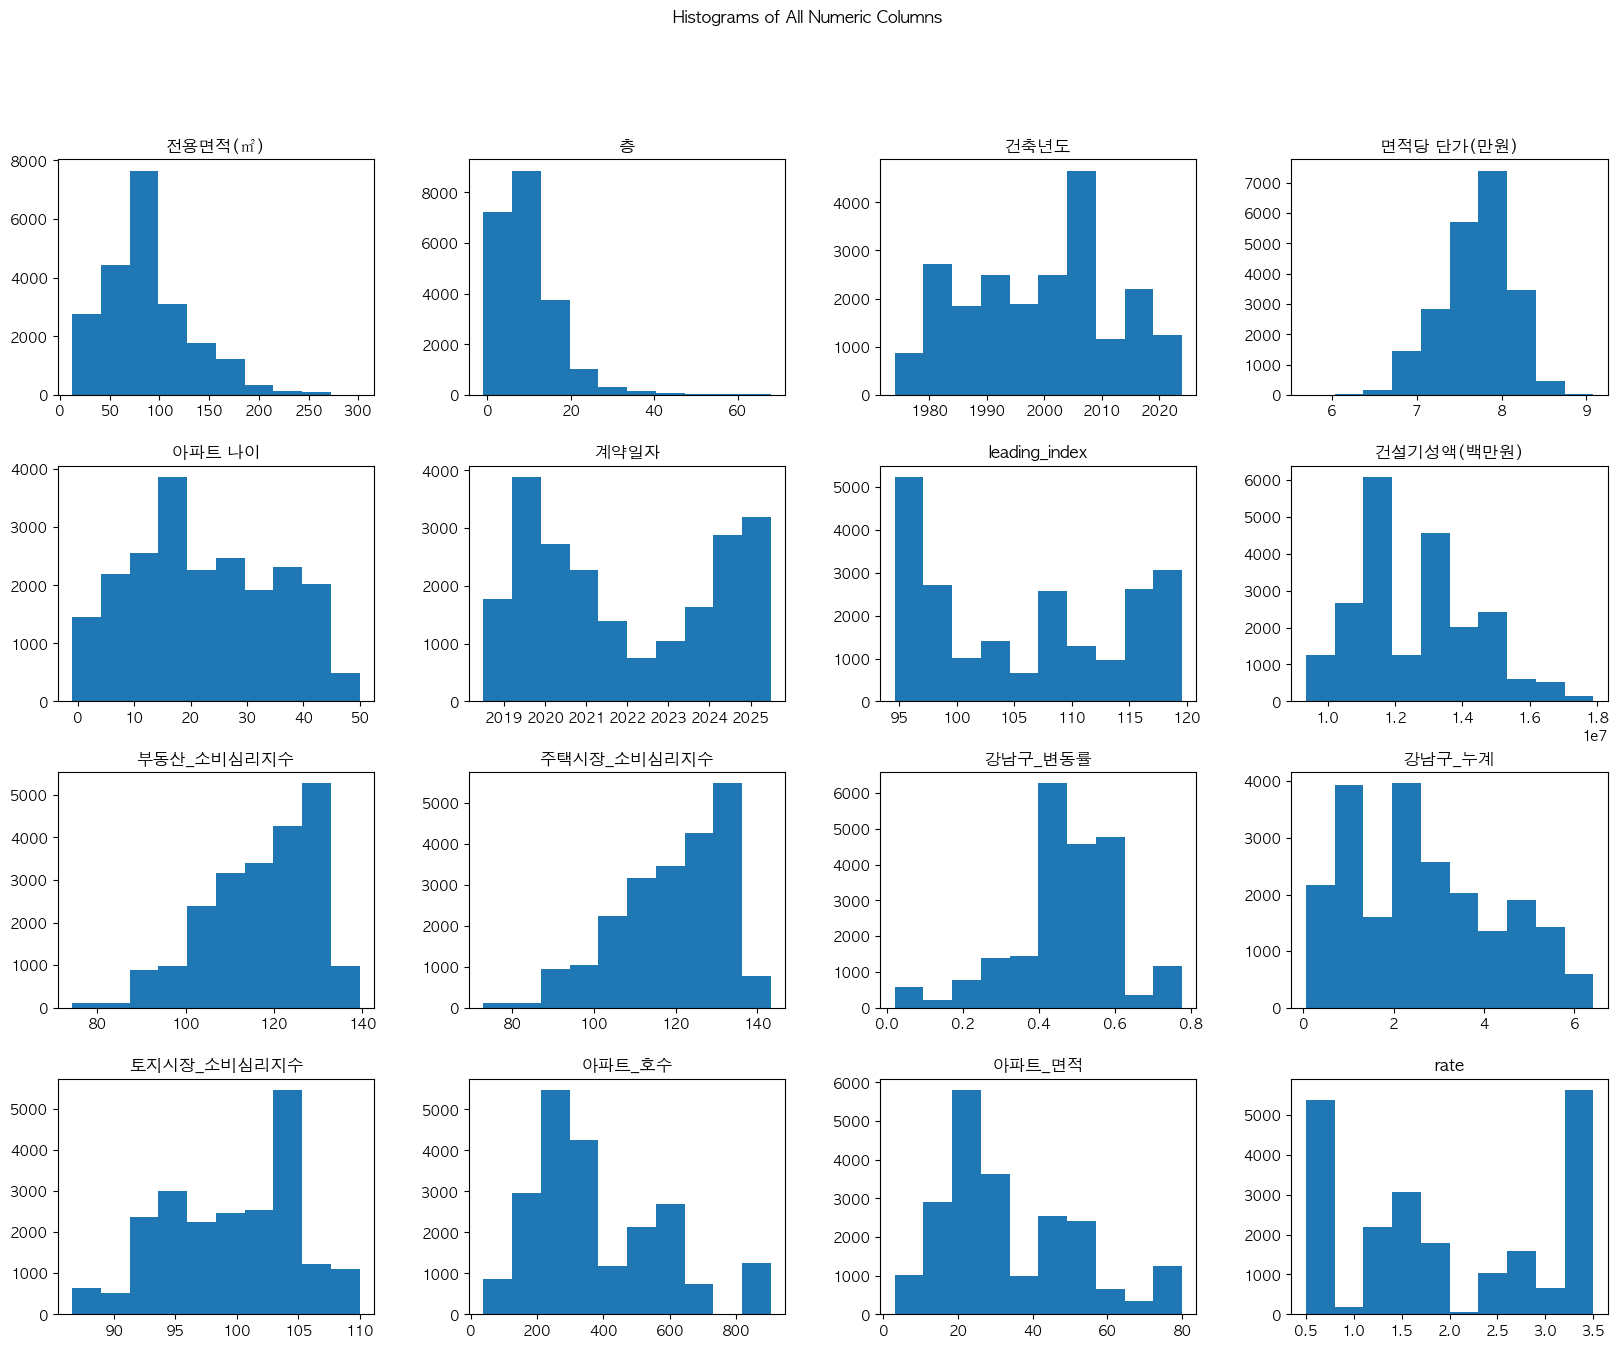

In [6]:
axes = df.hist(figsize=(20, 15), bins=10)
plt.suptitle("Histograms of All Numeric Columns")

for ax in axes.ravel():
    ax.grid(False)
plt.show()

In [7]:
df['계약일자'].min()

Timestamp('2018-07-01 00:00:00')

In [8]:
df['계약일자'].max()

Timestamp('2025-06-30 00:00:00')

In [9]:
df['date'] = df['계약일자'].dt.strftime('%Y-%m')

In [10]:
# 2-2. 이미지 전체 경로 생성
df['image_filename'] = [f'apt_image_{i}{IMAGE_EXTENSION}' for i in df.index]
df['image_path'] = df['image_filename'].apply(lambda filename: os.path.join(IMAGE_DIRECTORY, filename))

# 2-3. 특징(X)과 타겟(y) 분리
X_tabular = df.drop(columns=[TARGET_COLUMN, DATE_COLUMN, 'image_path', 'image_filename', 'date'])
y_target = df[TARGET_COLUMN]

# 2-4. 숫자형 특징 스케일링
#print("2. 데이터를 전처리합니다...")
numeric_features = X_tabular.select_dtypes(include=np.number).columns.tolist()
#scaler = StandardScaler()
#scaler = RobustScaler()
scaler = MinMaxScaler()
X_tabular[numeric_features] = scaler.fit_transform(X_tabular[numeric_features])
print("=========================")
print("최종 전처리 완료된 데이터 입니다.")
print("=========================\n")
df.info()

최종 전처리 완료된 데이터 입니다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21561 entries, 0 to 21560
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   전용면적(㎡)         21561 non-null  float64       
 1   층               21561 non-null  int64         
 2   건축년도            21561 non-null  int64         
 3   면적당 단가(만원)      21561 non-null  float64       
 4   아파트 나이          21561 non-null  int64         
 5   계약일자            21561 non-null  datetime64[ns]
 6   leading_index   21561 non-null  float64       
 7   건설기성액(백만원)      21561 non-null  float64       
 8   부동산_소비심리지수      21561 non-null  float64       
 9   주택시장_소비심리지수     21561 non-null  float64       
 10  강남구_변동률         21561 non-null  float64       
 11  강남구_누계          21561 non-null  float64       
 12  토지시장_소비심리지수     21561 non-null  float64       
 13  아파트_호수          21561 non-null  float64       
 14  아파트_면적          21561 non-null  f

In [11]:
X_tabular.describe()

,전용면적(㎡),층,건축년도,아파트 나이,leading_index,건설기성액(백만원),부동산_소비심리지수,주택시장_소비심리지수,강남구_변동률,강남구_누계,토지시장_소비심리지수,아파트_호수,아파트_면적,rate
count,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000,21561.000000
mean,0.265853,0.152923,0.498346,0.461230,0.452095,0.372808,0.660744,0.658914,0.594297,0.417731,0.554138,0.399785,0.401807,0.485676
std,0.145915,0.110434,0.246084,0.241477,0.342958,0.201767,0.187750,0.187627,0.191705,0.254703,0.225254,0.229519,0.234610,0.379998
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.165134,0.072464,0.280000,0.274510,0.112000,0.210609,0.545315,0.542614,0.509259,0.195792,0.371795,0.240506,0.246753,0.166667
50%,0.250786,0.130435,0.540000,0.431373,0.476000,0.362527,0.692780,0.684659,0.603175,0.392055,0.585470,0.338320,0.337662,0.333333
75%,0.341155,0.202899,0.660000,0.647059,0.824000,0.516812,0.817204,0.811080,0.720899,0.584236,0.739316,0.560414,0.558442,0.916667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


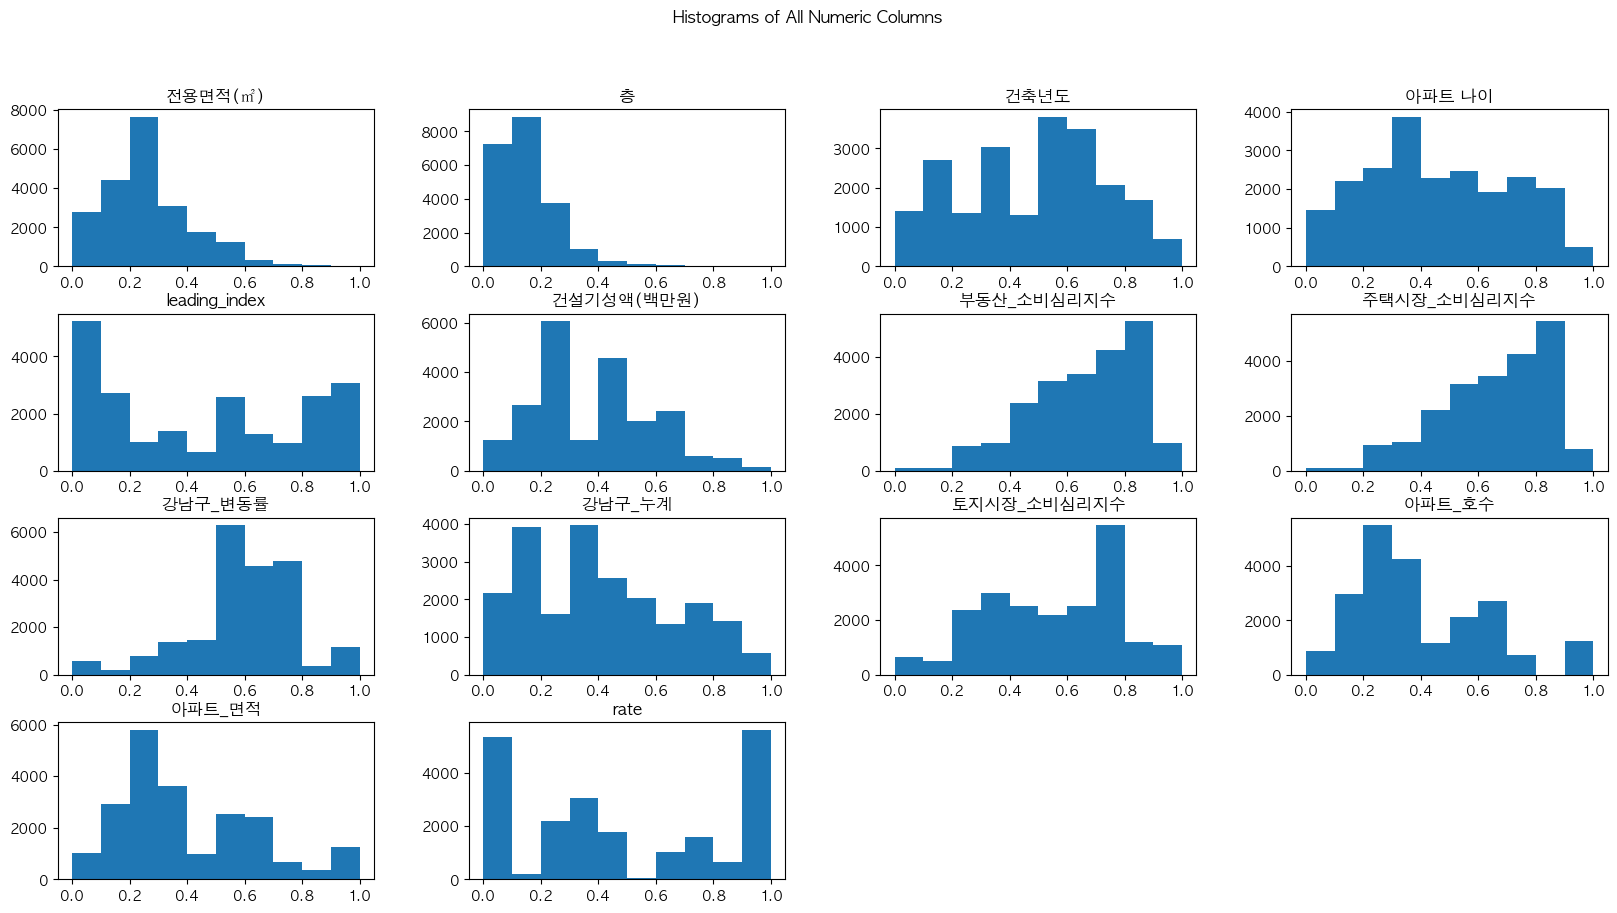

In [12]:
axes = X_tabular.hist(figsize=(20, 10), bins=10)
plt.suptitle("Histograms of All Numeric Columns")

for ax in axes.ravel():
    ax.grid(False)
plt.show()

# 다중 모달 특징 추출

In [13]:
# --- 3. 다중 모달 특징 추출 ---

# 3-1. 특징 추출기 모델 정의 (수정 없음, Input 레이어의 name이 중요해짐)
print("3. 특징 추출기 모델을 정의합니다...")
def create_feature_extractor_model(num_tabular_features, image_shape=(224, 224, 3)):
    # --- 입력층 정의 ---
    # 1. 인구통계, 주택 관련, KDE 특징을 포함하는 정형 데이터 입력
    tabular_input = Input(shape=(num_tabular_features,), name='tabular_input')
    # 2. 이미지 데이터 입력
    image_input = Input(shape=image_shape, name='image_input')
    
    
    # --- 특징별 처리 스트림 ---
    
    # 이미지 특징 처리 부분 (3개의 은닉층) 
    base_cnn = ResNet50(weights='imagenet', include_top=False, input_tensor=image_input)
    base_cnn.trainable = False
    x_image = GlobalAveragePooling2D()(base_cnn.output)
    x_image = Dense(128, activation='relu')(x_image)
    # 정형 모델과 출력층을 맞춰서 큰 특징에 의존하지 않도록 64로 출력하도록 설정함 (9.19)
    image_features = Dense(64, activation='relu')(x_image)
    #image_features = Dense(32, activation='relu')(x_image)

    # 정형 데이터(인구통계, 주택, KDE) 처리 부분 (1개의 은닉층) 
    tabular_features = Dense(64, activation='relu')(tabular_input)

    
    # --- 특징 결합 및 최종 예측 ---
    
    # 두 부분의 출력을 결합 
    combined = Concatenate()([image_features, tabular_features])
    normalized_featurees = BatchNormalization()(combined)
    
    # 결합된 특징을 256개 뉴런을 가진 은닉층으로 처리 
    x = Dense(256, activation='relu')(normalized_featurees)
    
    # 최종 가격을 예측하는 출력 뉴런 
    # 벡터형태로 LSTM에 넘겨야해서 주석처리 ㄱㄱ
    # prediction = Dense(1, activation='linear', name='price_output')(x)
    
    # --- 모델 생성 ---
    model = Model(inputs=[tabular_input, image_input], outputs=x, name='apartment_predictor')
    
    return model

# 3-2. 특징 추출을 위한 데이터 제너레이터 (수정됨)
def prediction_generator(tabular_data, image_paths, batch_size, image_shape=(224,224,3)):
    num_samples = len(tabular_data)
    for offset in range(0, num_samples, batch_size):
        batch_tabular = tabular_data.iloc[offset:offset+batch_size].values.astype(np.float32)
        batch_paths = image_paths.iloc[offset:offset+batch_size]
        
        batch_images = []
        for path in batch_paths:
            try:
                img = load_img(path, target_size=image_shape[:2])
                img_array = img_to_array(img) / 255.0
                batch_images.append(img_array)
            except FileNotFoundError:
                batch_images.append(np.zeros(image_shape, dtype=np.float32))
        
        yield {
            'tabular_input': np.array(batch_tabular, dtype=np.float32),
            'image_input': np.array(batch_images, dtype=np.float32)
        }

# 3-3. 전체 데이터에 대한 특징 추출 실행 
print("4. 전체 데이터에 대한 특징을 추출합니다...")
feature_extractor = create_feature_extractor_model(num_tabular_features=X_tabular.shape[1])

# 출력 형식을 딕셔너리 구조로 명시
output_signature = {
    'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
    'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
}

# from_generator를 사용하여 데이터셋 생성
pred_dataset = tf.data.Dataset.from_generator(
    # 수정: 올바른 DataFrame 'X_tabular' 사용
    lambda: prediction_generator(X_tabular, df['image_path'], BATCH_SIZE),
    output_signature={
        # 수정: 형태(shape)를 가져오기 위해 올바른 DataFrame 'X_tabular' 사용
        'tabular_input': tf.TensorSpec(shape=(None, X_tabular.shape[1]), dtype=tf.float32),
        'image_input': tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32)
    }
)


# predict 함수에 tf.data.Dataset을 직접 전달
all_features = feature_extractor.predict(pred_dataset, verbose=1)

print("\n🎉 특징 추출이 성공적으로 완료되었습니다!")
print("추출된 특징의 모양:", all_features.shape)

3. 특징 추출기 모델을 정의합니다...
4. 전체 데이터에 대한 특징을 추출합니다...


2025-09-19 09:44:46.741060: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-09-19 09:44:46.760283: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


337/337 [==============================] - 431s 1s/step

🎉 특징 추출이 성공적으로 완료되었습니다!
추출된 특징의 모양: (21561, 256)


In [14]:
np.save('../../data/final/all_feature',all_features)

# 시퀀스 데이터 생성

In [52]:
# --- 4. 시퀀스 데이터 생성 ---

print("\n5. 시계열 데이터를 생성합니다...")
def create_sequences(X_data, y_data, lookback):
    X_sequences, y_sequences = [], []
    # 데이터 길이에서 lookback 길이를 뺀 만큼 반복
    for i in range(len(X_data) - lookback):
        # i부터 i+lookback까지의 데이터를 하나의 시퀀스로
        X_sequences.append(X_data[i:(i + lookback)])
        # 시퀀스 바로 다음의 데이터를 정답으로
        y_sequences.append(y_data[i + lookback])
    return np.array(X_sequences), np.array(y_sequences)

# 이전 단계에서 추출한 all_features와 원본 정답(y_target)을 사용
X_seq, y_seq = create_sequences(all_features, y_target.values, lookback=LOOKBACK)

print(f"생성된 시퀀스 데이터 모양 (X): {X_seq.shape}") # (샘플 수, 10, 96)
print(f"생성된 시퀀스 데이터 모양 (y): {y_seq.shape}") # (샘플 수,)


# 4-1. 훈련/테스트 데이터 분리 (시계열 데이터는 순서를 섞지 않음)
split_index = int(len(X_seq) * 0.8)
X_train_seq, X_test_seq = X_seq[:split_index], X_seq[split_index:]
y_train_seq, y_test_seq = y_seq[:split_index], y_seq[split_index:]



5. 시계열 데이터를 생성합니다...
생성된 시퀀스 데이터 모양 (X): (21551, 10, 256)
생성된 시퀀스 데이터 모양 (y): (21551,)


# 예측

In [83]:
def create_lstm_model(input_shape):
    input_layer = Input(shape=input_shape)
    x = LSTM(128, activation='relu', return_sequences=True)(input_layer)
    x = Dropout(0.2)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)  
    prediction = Dense(1, activation='linear')(x)

    model = Model(inputs=input_layer, outputs=prediction, name='lstm_forecaster')
    return model

In [84]:
def create_future_sequences(all_features, original_df, lookback=10, horizon_days=30):
    """
    특정 기간(horizon_days) 후의 가격을 예측하기 위한 시계열 데이터를 생성합니다.
    
    :param all_features: (샘플 수, 특징 수) 모양의 전체 특징 데이터
    :param original_df: 날짜와 타겟 컬럼이 포함된 원본 데이터프레임
    :param lookback: 과거를 돌아볼 기간 (시퀀스 길이)
    :param horizon_days: 예측할 미래 기간 (일 단위)
    :return: X_sequences (입력 시퀀스), y_sequences (미래 시점의 정답)
    """
    X_sequences, y_sequences = [], []
    
    # 날짜와 타겟 값을 쉽게 조회할 수 있도록 Series로 변환
    dates = original_df['계약일자']
    targets = original_df[TARGET_COLUMN].values
    
    for i in range(len(all_features) - lookback):
        # 입력 시퀀스의 마지막 날짜
        end_of_input_sequence_date = dates[i + lookback - 1]
        
        # 예측 목표 날짜 설정
        target_date = end_of_input_sequence_date + pd.Timedelta(days=horizon_days)
        
        # 목표 날짜 이후의 데이터만 필터링
        future_data_indices = np.where(dates >= target_date)[0]
        
        # 목표 날짜 이후에 거래가 있다면
        if len(future_data_indices) > 0:
            # 가장 가까운 미래 거래의 인덱스를 찾음
            future_target_index = future_data_indices[0]
            
            # 해당 인덱스가 전체 특징 데이터 길이를 벗어나지 않는지 확인
            if future_target_index < len(all_features):
                # 입력 시퀀스 생성
                X_sequences.append(all_features[i:(i + lookback)])
                # 미래 시점의 가격을 정답으로 지정
                y_sequences.append(targets[future_target_index])
                
    return np.array(X_sequences), np.array(y_sequences)

In [85]:
# --- 4. 시퀀스 데이터 생성 (미래 예측용) ---

print("\n5. 미래 예측을 위한 시계열 데이터를 생성합니다...")

# 1개월 (약 30일) 후 가격 예측용 데이터셋 생성
print("1개월 후 예측 데이터셋 생성 중...")
X_seq_1m, y_seq_1m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=30)

# 3개월 (약 90일) 후 가격 예측용 데이터 생성함요
print("3개월 후 예측 데이터셋 생성 중...")
X_seq_3m, y_seq_3m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=60)

# 6개월 (약 180일) 후 가격 예측용 데이터셋 생성
print("6개월 후 예측 데이터셋 생성 중...")
X_seq_6m, y_seq_6m = create_future_sequences(all_features, df, lookback=LOOKBACK, horizon_days=180)

print("\n======================================\n")
print(f"1개월 후 예측용 데이터 샘플 수: {len(X_seq_1m)}")
print(f"3개월 후 예측용 데이터 샘플 수: {len(X_seq_3m)}")
print(f"6개월 후 예측용 데이터 샘플 수: {len(X_seq_6m)}")


5. 미래 예측을 위한 시계열 데이터를 생성합니다...
1개월 후 예측 데이터셋 생성 중...
3개월 후 예측 데이터셋 생성 중...
6개월 후 예측 데이터셋 생성 중...


1개월 후 예측용 데이터 샘플 수: 20980
3개월 후 예측용 데이터 샘플 수: 20719
6개월 후 예측용 데이터 샘플 수: 18906


In [86]:
# --- 5-1 1개월 후 예측 모델 학습 ---

# 1, 3, 6개월 모델의 옵티마이저는 여기서 설정
optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)

# 'val_loss'(검증 손실)를 모니터링하면서, 5번의 에포크 동안 성능 개선이 없으면 학습을 중단합니다.
# restore_best_weights=True 옵션은 가장 성능이 좋았던 시점의 가중치로 모델을 되돌려줍니다.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 데이터 분리
split_1m = int(len(X_seq_1m) * 0.8)
X_train_1m, X_test_1m = X_seq_1m[:split_1m], X_seq_1m[split_1m:]
y_train_1m, y_test_1m = y_seq_1m[:split_1m], y_seq_1m[split_1m:]

In [87]:
# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_1m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.00001)
lstm_model_1m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 1개월 후 예측 모델 학습 시작 ---")
history_1m = lstm_model_1m.fit(
    X_train_1m, y_train_1m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1m, y_test_1m),
    callbacks=[early_stopping],
    verbose=1
)

# --- 5-2 3개월 후 예측 모델 학습 ---

# 데이터 분리
split_3m = int(len(X_seq_3m) * 0.8)
X_train_3m, X_test_3m = X_seq_3m[:split_3m], X_seq_3m[split_3m:]
y_train_3m, y_test_3m = y_seq_3m[:split_3m], y_seq_3m[split_3m:]

# 모델 생성 및 컴파일 (모델 구조는 동일)
lstm_model_3m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))
# ❗️[추천] 학습률 조정 및 활성화 함수 변경
#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_3m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 3개월 후 예측 모델 학습 시작 ---")
history_3m = lstm_model_3m.fit(
    X_train_3m, y_train_3m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3m, y_test_3m),
    callbacks=[early_stopping],
    verbose=1
)


# --- 5-3 6개월 후 예측 모델 학습 ---

# 데이터 분리
split_6m = int(len(X_seq_6m) * 0.8)
X_train_6m, X_test_6m = X_seq_6m[:split_6m], X_seq_6m[split_6m:]
y_train_6m, y_test_6m = y_seq_6m[:split_6m], y_seq_6m[split_6m:]

# 모델 생성 및 컴파일
lstm_model_6m = create_lstm_model(input_shape=(LOOKBACK, all_features.shape[1]))

#optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
lstm_model_6m.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

print("\n--- 6개월 후 예측 모델 학습 시작 ---")
history_6m = lstm_model_6m.fit(
    X_train_6m, y_train_6m,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_6m, y_test_6m),
    callbacks=[early_stopping],
    verbose=1
)


--- 1개월 후 예측 모델 학습 시작 ---
Epoch 1/100
263/263 [==============================] - 3s 10ms/step - loss: 53.5067 - mae: 7.2984 - val_loss: 52.3998 - val_mae: 7.2081
Epoch 2/100
263/263 [==============================] - 3s 11ms/step - loss: 33.4889 - mae: 5.3907 - val_loss: 29.6965 - val_mae: 4.8807
Epoch 3/100
263/263 [==============================] - 3s 11ms/step - loss: 23.7881 - mae: 4.1987 - val_loss: 20.8471 - val_mae: 3.5666
Epoch 4/100
263/263 [==============================] - 3s 11ms/step - loss: 16.6438 - mae: 3.1292 - val_loss: 15.1779 - val_mae: 2.7185
Epoch 5/100
263/263 [==============================] - 3s 11ms/step - loss: 12.7250 - mae: 2.5099 - val_loss: 11.9177 - val_mae: 2.2316
Epoch 6/100
263/263 [==============================] - 3s 11ms/step - loss: 10.2782 - mae: 2.1262 - val_loss: 9.7380 - val_mae: 1.8784
Epoch 7/100
263/263 [==============================] - 3s 11ms/step - loss: 8.5700 - mae: 1.8693 - val_loss: 8.1745 - val_mae: 1.6717
Epoch 8/100
263/263 [===


--- 3개월 후 예측 모델 학습 시작 ---
Epoch 1/100
259/259 [==============================] - 3s 10ms/step - loss: 55.0989 - mae: 7.4091 - val_loss: 55.7659 - val_mae: 7.4514
Epoch 2/100
259/259 [==============================] - 3s 11ms/step - loss: 37.6531 - mae: 5.8345 - val_loss: 29.8279 - val_mae: 4.9075
Epoch 3/100
259/259 [==============================] - 3s 11ms/step - loss: 24.2582 - mae: 4.2792 - val_loss: 21.5878 - val_mae: 3.7747
Epoch 4/100
259/259 [==============================] - 3s 11ms/step - loss: 16.8463 - mae: 3.1725 - val_loss: 15.2778 - val_mae: 2.7968
Epoch 5/100
259/259 [==============================] - 3s 10ms/step - loss: 12.7735 - mae: 2.5238 - val_loss: 11.9118 - val_mae: 2.2883
Epoch 6/100
259/259 [==============================] - 3s 11ms/step - loss: 10.3081 - mae: 2.1345 - val_loss: 9.7193 - val_mae: 1.8852
Epoch 7/100
259/259 [==============================] - 3s 11ms/step - loss: 8.6003 - mae: 1.8602 - val_loss: 8.1882 - val_mae: 1.6835
Epoch 8/100
259/259 [===


--- 6개월 후 예측 모델 학습 시작 ---
Epoch 1/100
237/237 [==============================] - 3s 11ms/step - loss: 54.3856 - mae: 7.3598 - val_loss: 54.6171 - val_mae: 7.3707
Epoch 2/100
237/237 [==============================] - 3s 11ms/step - loss: 36.8813 - mae: 5.7696 - val_loss: 30.7299 - val_mae: 5.0208
Epoch 3/100
237/237 [==============================] - 3s 11ms/step - loss: 25.1102 - mae: 4.4079 - val_loss: 23.8100 - val_mae: 4.1532
Epoch 4/100
237/237 [==============================] - 2s 10ms/step - loss: 18.2206 - mae: 3.3974 - val_loss: 16.3906 - val_mae: 3.0616
Epoch 5/100
237/237 [==============================] - 2s 10ms/step - loss: 13.7000 - mae: 2.7079 - val_loss: 12.5719 - val_mae: 2.3330
Epoch 6/100
237/237 [==============================] - 2s 10ms/step - loss: 10.9222 - mae: 2.2560 - val_loss: 10.2464 - val_mae: 1.9969
Epoch 7/100
237/237 [==============================] - 3s 11ms/step - loss: 9.0604 - mae: 1.9598 - val_loss: 8.5028 - val_mae: 1.7211
Epoch 8/100
237/237 [==

In [88]:
import matplotlib.pyplot as plt
import pandas as pd # pd.Series를 위해 import
import numpy as np # np.expm1을 위해 import
from sklearn.metrics import mean_absolute_error

# --- 분석 및 시각화 함수 수정 ---
def analyze_and_visualize_model(model, X_test_seq, y_test_seq, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행 (로그 스케일)
    y_pred_log = model.predict(X_test_seq)

    # ❗️ [수정] y_pred_log의 차원 확인 및 조정
    if y_pred_log.ndim >= 2:
        y_pred_log = y_pred_log.flatten()

    # 2. 역변환 (로그 -> 원본 단위)
    y_pred_original = np.expm1(y_pred_log)

    # ❗️ [수정] y_test_seq도 동일하게 차원 조정 및 역변환
    y_test_original = np.expm1(y_test_seq)
    
    if y_test_original.ndim >= 2:
        y_test_original = y_test_original.flatten()
        
    # ❗️ [수정] 두 배열의 길이를 동일하게 맞춰줍니다.
    #    예측값의 길이를 기준으로 실제값의 길이를 자릅니다.
    min_len = min(len(y_test_original), len(y_pred_original))
    y_test_np = y_test_original[:min_len]
    y_pred_original = y_pred_original[:min_len]


    # 3. 원본 단위(만원)로 MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(min(5, len(y_test_np))):
        print(f"실제 단가: {y_test_np[i]:.2f} (만원)  |  예측 단가: {y_pred_original[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    print(f"Real World MAE: {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    
    min_val = min(y_test_np.min(), y_pred_original.min())
    max_val = max(y_test_np.max(), y_pred_original.max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()


--- 1개월 후 예측 모델 성능 분석 시작 ---
132/132 [==============================] - 0s 3ms/step
--- 1개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1385.35 (만원)  |  예측 단가: 2505.03 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2402.55 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2839.06 (만원)
실제 단가: 1385.35 (만원)  |  예측 단가: 2821.48 (만원)
실제 단가: 3639.78 (만원)  |  예측 단가: 2281.98 (만원)

--- 1개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1258.81 (만원)


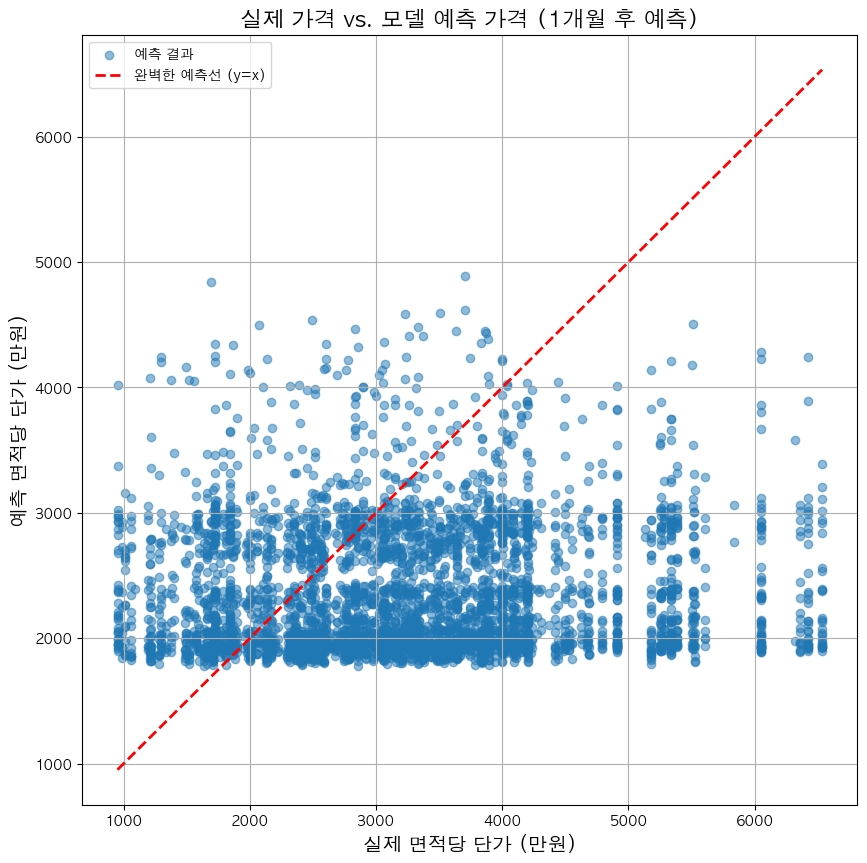


--- 3개월 후 예측 모델 성능 분석 시작 ---
130/130 [==============================] - 0s 2ms/step
--- 3개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 1206.20 (만원)  |  예측 단가: 3446.13 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2100.55 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2515.84 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 2103.90 (만원)
실제 단가: 1206.20 (만원)  |  예측 단가: 1989.26 (만원)

--- 3개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1353.99 (만원)


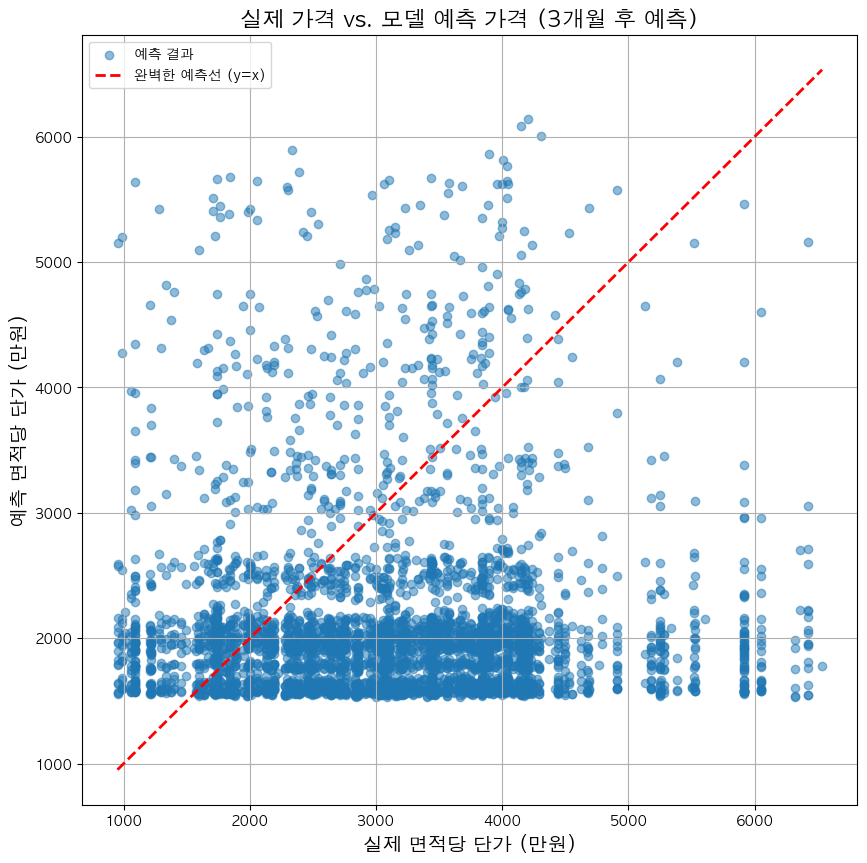


--- 6개월 후 예측 모델 성능 분석 시작 ---
119/119 [==============================] - 0s 2ms/step
--- 6개월 후 예측: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---
실제 단가: 2605.93 (만원)  |  예측 단가: 1979.85 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2273.16 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2316.98 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2277.86 (만원)
실제 단가: 3738.83 (만원)  |  예측 단가: 2059.03 (만원)

--- 6개월 후 예측: 최종 실제 오차 (원본 단위) ---
Real World MAE: 1281.52 (만원)


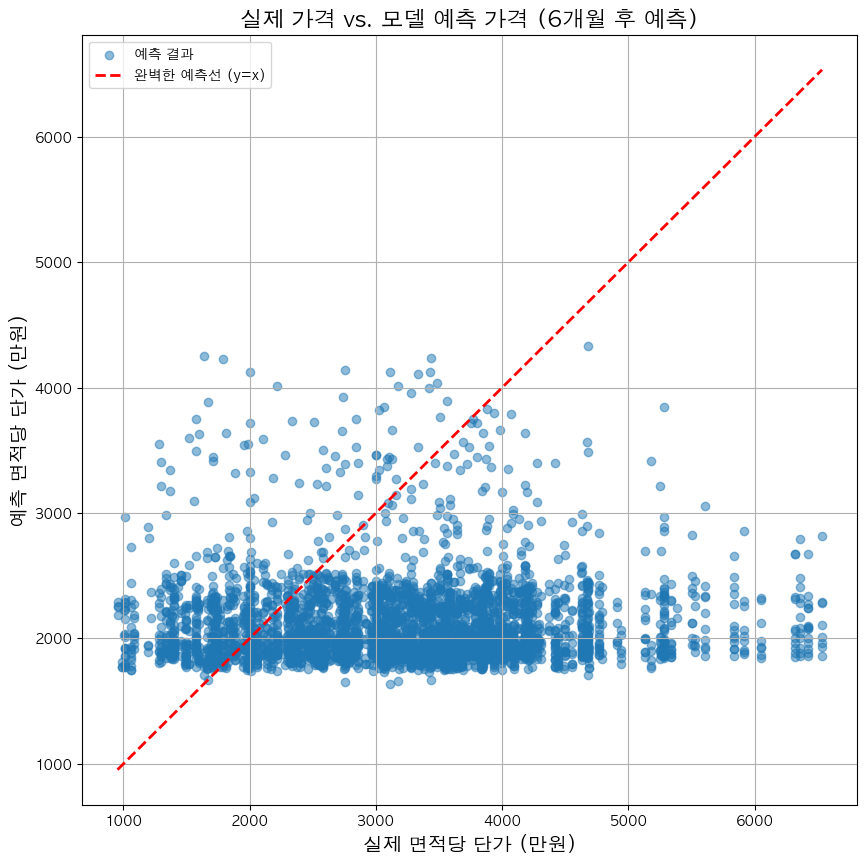

In [89]:

# --- 함수 실행 (기존 코드와 동일) ---
# 1개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_1m, X_test_1m, y_test_1m, "1개월 후 예측")

# 3개월 후 예측 모델 분석
analyze_and_visualize_model(lstm_model_3m, X_test_3m, y_test_3m, "3개월 후 예측")

# 6개월 후 예측 모델 분석 (만약 모델이 있다면)
analyze_and_visualize_model(lstm_model_6m, X_test_6m, y_test_6m, "6개월 후 예측")


In [90]:
# 시계열이 아닌 개별 데이터를 사용하므로, 시퀀스 생성을 하지 않습니다.
# all_features와 y_target을 짝에 맞게 분리합니다.
split_point = int(len(all_features) * 0.8)

In [91]:
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

def create_mlp_model(input_shape):
    input_layer = Input(shape=(input_shape,))
    x = Dense(128, activation='relu')(input_layer)
    x = Dense(64, activation='relu')(x)
    x = Dense(32, activation='relu')(x)
    # x = Dense(16, activation='relu')(x)
    # x = Dense(8, activation='relu')(x)
    prediction = Dense(1, activation='linear')(x)
    model = Model(inputs=input_layer, outputs=prediction)
    return model

# MLP 모델 생성 및 학습
mlp_model = create_mlp_model(X_train.shape[1])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
mlp_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])
mlp_model.summary()

history = mlp_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# 이 모델의 예측 결과를 시각화하여 수평선이 나오는지 확인합니다.

NameError: name 'X' is not defined

In [ ]:
# --- 분석 및 시각화 함수 (수정된 버전) ---
def analyze_and_visualize_model(model, X_test_data, y_test_data, model_name):
    """
    학습된 모델의 성능을 분석하고 결과를 시각화하는 함수
    """
    print(f"\n--- {model_name} 모델 성능 분석 시작 ---")
    
    # 1. 예측 수행
    y_pred_log = model.predict(X_test_data)

    # 2. 역변환
    y_test_original = np.exp(y_test_data)
    y_pred_original = np.exp(y_pred_log)
    
    # ❗️ [수정] Series일 경우를 대비하여 .values를 사용, NumPy 배열로 통일
    y_test_np = y_test_original.values if isinstance(y_test_original, pd.Series) else y_test_original
    # model.predict의 결과는 이미 NumPy 배열이므로 y_pred_original은 그대로 사용
    
    # 3. MAE 계산
    real_world_mae = mean_absolute_error(y_test_np, y_pred_original)

    # 4. 결과 출력
    print(f"--- {model_name}: 실제 값 vs 예측 값 비교 (원본 단위, 상위 5개) ---")
    for i in range(5):
        # ❗️ [수정] .flatten()을 안전하게 사용하기 위해 NumPy 배열인 y_test_np를 사용
        print(f"실제 단가: {y_test_np.flatten()[i]:.2f} (만원)  |  예측 단가: {y_pred_original.flatten()[i]:.2f} (만원)")

    print(f"\n--- {model_name}: 최종 실제 오차 (원본 단위) ---")
    _, scaled_mae = model.evaluate(X_test_data, y_test_data, verbose=0)
    print(f"모델 평가 결과 (Log Scaled MAE): {scaled_mae:.4f}")
    print(f"역변환 후 실제 오차 (Real World MAE): {real_world_mae:.2f} (만원)")

    # 5. 시각화
    plt.figure(figsize=(10, 10))
    # ❗️ [수정] 시각화 시에도 NumPy 배열인 y_test_np를 사용
    plt.scatter(y_test_np, y_pred_original, alpha=0.5, label='예측 결과')
    plt.plot([min(y_test_np.flatten()), max(y_test_np.flatten())], 
             [min(y_test_np.flatten()), max(y_test_np.flatten())], 
             '--r', linewidth=2, label='완벽한 예측선 (y=x)')
    plt.xlabel("실제 면적당 단가 (만원)", fontsize=14)
    plt.ylabel("예측 면적당 단가 (만원)", fontsize=14)
    plt.title(f"실제 가격 vs. 모델 예측 가격 ({model_name})", fontsize=16)
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 함수 재호출 ---
# 이제 MLP 모델에 대한 분석을 다시 실행합니다.
analyze_and_visualize_model(mlp_model, X_test, y_test, "MLP 기본 모델")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

# --- 1. 데이터 준비 (X_tabular 사용) ---
# X_tabular: 숫자형으로 변환된 정형 데이터 DataFrame (8개 특징)
# y_target: 로그 변환된 타겟 변수 (Series)
# (두 변수는 이전 코드에서 이미 생성되어 있어야 합니다)

X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(
    X_tabular,
    y_target,
    test_size=0.2,
    random_state=42
)

# --- 2. 새로운 XGBoost 모델 학습 ---
print("해석 가능한 특징으로 새로운 XGBoost 모델을 학습합니다...")
xgb_interpretable_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20
)

# 모델 학습
xgb_interpretable_model.fit(
    X_train_tab, y_train_tab,
    eval_set=[(X_test_tab, y_test_tab)],
    verbose=False
)

# --- 3. 변수 중요도 추출 및 시각화 ---
# 이제 모델의 특징 개수와 X_train_tab의 컬럼 개수가 일치합니다.
feature_importances = pd.Series(
    xgb_interpretable_model.feature_importances_, 
    index=X_train_tab.columns
)

# 한글 폰트 설정 (이전에 설정했다면 생략 가능)
try:
    font_name = fm.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    plt.rc('font', family=font_name)
except FileNotFoundError:
    print("Malgun Gothic 폰트를 찾을 수 없어 기본 폰트로 시각화합니다.")
plt.rc('axes', unicode_minus=False)

# 가장 중요한 특징들을 시각화
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost 모델의 변수 중요도 (정형 데이터)', fontsize=16)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(True, axis='x', linestyle='--')
plt.show()